## Preparación de Datos para el Modelo

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report, confusion_matrix

# 1. Cargamos la tabla analítica y eliminamos columnas que no aportan valor predictivo (fechas e identificadores)
df = pd.read_csv("../../datos/procesados/abt_socios_modelo.csv")
columnas_a_eliminar = ['id_socio', 'fecha_nacimiento', 'fecha_alta', 'fecha_baja', 'tipo_cuota', 'codigo_postal']
df_ml = df.drop(columns=columnas_a_eliminar, errors='ignore')

# 2. Convertimos las variables categóricas en numéricas para que el algoritmo pueda procesarlas matemáticamente
df_ml = pd.get_dummies(df_ml, columns=['sexo', 'tipo_socio'], drop_first=True)

# 3. Separamos la variable objetivo (lo que queremos predecir) del resto de características
X = df_ml.drop('es_baja', axis=1)
y = df_ml['es_baja']

# 4. Dividimos los datos: 80% de train y 20% de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

resultados_modelos = []

print("Datos listos para entrenar. Tamaño de X_train:", X_train.shape)

Datos listos para entrenar. Tamaño de X_train: (6926, 40)


## Modelo 1: Regresión Logística

In [9]:
from sklearn.linear_model import LogisticRegression

print("Entrenando Regresión Logística...")

# 1. Configuramos el modelo de Regresión Logística con un límite alto de iteraciones para asegurar que encuentre la solución matemática
modelo_lr = LogisticRegression(max_iter=3000, random_state=42)

# 2. Entrenamos el algoritmo pasándole los datos históricos para que aprenda los patrones que llevan a una baja
modelo_lr.fit(X_train, y_train)

# 3. Le pedimos al modelo ya entrenado que intente predecir las bajas utilizando los datos de prueba que hemos reservado
y_pred_lr = modelo_lr.predict(X_test)

# 4. Calculamos y guardamos las métricas de evaluación (Accuracy, Recall y F1) para compararlo posteriormente con otros modelos
resultados_modelos.append({
    "Modelo": "Regresión Logística",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Recall (Bajas)": recall_score(y_test, y_pred_lr),
    "F1-Score": f1_score(y_test, y_pred_lr)
})
print("Regresión Logística completada.")

Entrenando Regresión Logística...
Regresión Logística completada.


## Modelo 2: Random Forest

In [10]:
from sklearn.ensemble import RandomForestClassifier

print("Entrenando Random Forest...")

# 1. Configuramos el modelo Random Forest, que creará 100 árboles de decisión diferentes para tomar una decisión conjunta
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Entrenamos el algoritmo con nuestros datos para que aprenda a identificar los perfiles de riesgo
modelo_rf.fit(X_train, y_train)

# 3. Le pedimos al modelo que evalúe a los socios del grupo de prueba y determine si se darán de baja
y_pred_rf = modelo_rf.predict(X_test)

# 4. Calculamos y guardamos las métricas de acierto en nuestra lista para compararlas posteriormente
resultados_modelos.append({
    "Modelo": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Recall (Bajas)": recall_score(y_test, y_pred_rf),
    "F1-Score": f1_score(y_test, y_pred_rf)
})
print("Random Forest completado.")

Entrenando Random Forest...
Random Forest completado.


## Modelo 3: XGBoost

In [11]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score
import joblib 

print("Entrenando XGBoost...")

# 1. Configuramos el modelo XGBoost
modelo_xgb = XGBClassifier(eval_metric='logloss', random_state=42)

# 2. Entrenamos el modelo con los datos históricos
modelo_xgb.fit(X_train, y_train)

# 3. Generamos las predicciones sobre el grupo de prueba
y_pred_xgb = modelo_xgb.predict(X_test)

# 4. Calculamos y registramos sus métricas de rendimiento
try:
    resultados_modelos.append({
        "Modelo": "XGBoost",
        "Accuracy": accuracy_score(y_test, y_pred_xgb),
        "Recall (Bajas)": recall_score(y_test, y_pred_xgb),
        "F1-Score": f1_score(y_test, y_pred_xgb)
    })
except NameError:
    print("Métricas calculadas:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb)}")
    print(f"Recall: {recall_score(y_test, y_pred_xgb)}")

print(f"XGBoost completado")

Entrenando XGBoost...
XGBoost completado


## RESULTADOS

In [12]:
# 1. Convertimos la lista de resultados en una tabla y la ordenamos destacando el modelo que mejor detecta las bajas (Recall)
df_resultados = pd.DataFrame(resultados_modelos).sort_values(by='Recall (Bajas)', ascending=False)

# 2. Redondeamos todos los valores matemáticos a tres decimales para que la información sea más fácil de leer
df_resultados = df_resultados.round(3)

# 3. Imprimimos un título descriptivo para nuestra sección de evaluación
print("TABLA DE RESULTADOS FINALES")

# 4. Mostramos la tabla definitiva por pantalla para poder comparar el rendimiento y elegir el algoritmo ganador
display(df_resultados)

TABLA DE RESULTADOS FINALES


,Modelo,Accuracy,Recall (Bajas),F1-Score
2,XGBoost,0.859,0.876,0.838
1,Random Forest,0.865,0.874,0.844
0,Regresión Logística,0.805,0.709,0.753


## Guardamos el modelo XGBoost para utilizarlo posteriormente

Pese a estar muy igualados el modelo de XGBoost y Random Forest, para predecir las bajas buscamos el modelo con mejor **Recall**, que, en este caso, el ganador es XGBoost

In [13]:
ruta_modelo = '../../datos/procesados/modelo_xgboost.pkl'
joblib.dump(modelo_xgb, ruta_modelo)

print(f"XGBoost guardado correctamente en: {ruta_modelo}")

XGBoost guardado correctamente en: ../../datos/procesados/modelo_xgboost.pkl


## Matriz de confusión

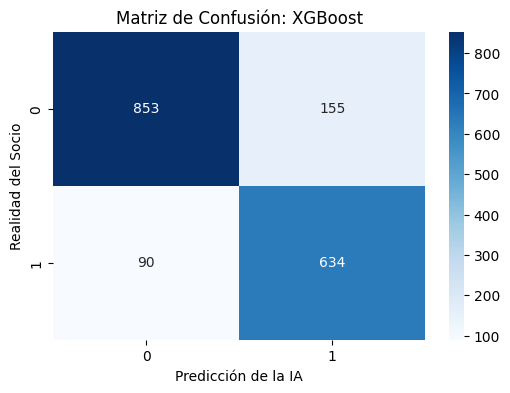

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculamos la matriz cruzando los datos reales de los socios con las predicciones que hizo XGBoost
matriz = confusion_matrix(y_test, y_pred_xgb)

# 2. Configuramos el tamaño del lienzo y creamos un mapa de calor para interpretar los resultados fácilmente
plt.figure(figsize=(6,4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues')

# 3. Asignamos títulos descriptivos a los ejes para saber qué representa cada lado y mostramos el gráfico
plt.title('Matriz de Confusión: XGBoost')
plt.xlabel('Predicción de la IA')
plt.ylabel('Realidad del Socio')
plt.show()

## Variebles más importantes de XGBoost

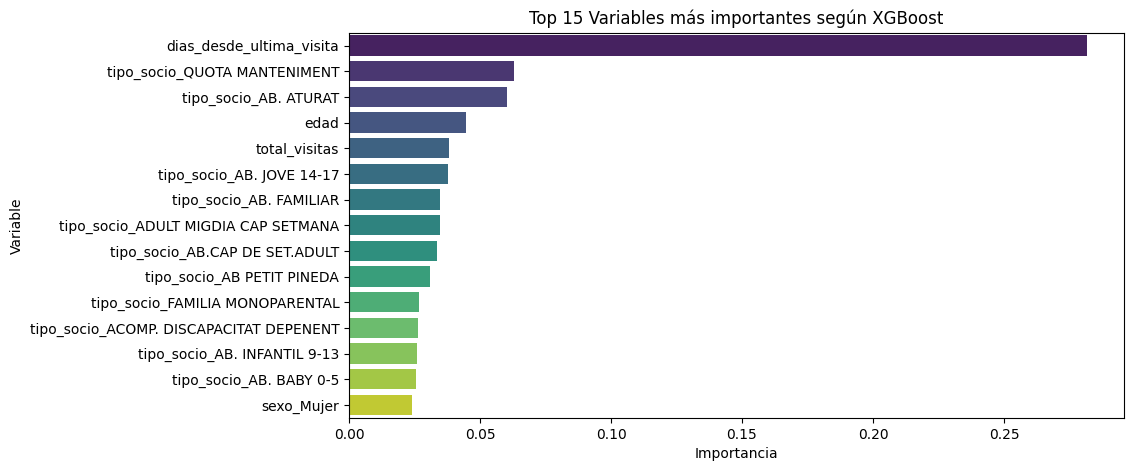

In [17]:
# 1. Extraemos el nivel de importancia que el modelo le ha dado a cada variable para tomar sus decisiones
importancias_xgb = modelo_xgb.feature_importances_

# 2. Creamos una tabla con las variables, las ordenamos de mayor a menor y seleccionamos las 15 principales
top_15_xgb = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias_xgb
}).sort_values(by='Importancia', ascending=False).head(15)

# 3. Configuramos el tamaño del lienzo y generamos un gráfico de barras horizontal para visualizar los datos
plt.figure(figsize=(10, 5))
sns.barplot(
    x='Importancia', 
    y='Variable', 
    data=top_15_xgb, 
    palette='viridis',
    hue='Variable',
    legend=False
)
# 4. Asignamos un título descriptivo al gráfico resultante y lo mostramos por pantalla
plt.title('Top 15 Variables más importantes según XGBoost')
plt.show()

## Identificación y Exportación de Socios en Riesgo

In [18]:
# 1. Filtramos el dataset para quedarnos unicamente con los socios que siguen apuntados actualmente al gimnasio
mascara_activos = df['es_baja'] == 0
X_activos = df_ml[mascara_activos].drop('es_baja', axis=1)
socios_activos = df[mascara_activos]

# 2. Utilizamos el modelo entrenado para calcular el porcentaje exacto de probabilidad que tiene cada socio de darse de baja
probabilidades_activos = modelo_xgb.predict_proba(X_activos)[:, 1]

# 3. Creamos una nueva tabla uniendo la probabilidad calculada con los datos clave que necesitara la IA para redactar los correos
df_predicciones = pd.DataFrame({
    'id_socio': socios_activos['id_socio'],
    'probabilidad_churn': probabilidades_activos,
    'zona_proximidad': socios_activos['zona_proximidad'],
    'total_visitas': socios_activos['total_visitas'],
    'dias_sin_venir': socios_activos['dias_desde_ultima_visita'],
    'edad': socios_activos['edad'],
    'tipo_socio': socios_activos['tipo_socio']
})

# 4. Aislamos a los socios que superan el umbral del 65% de riesgo y exportamos esta lista definitiva a un archivo CSV
socios_en_riesgo = df_predicciones[df_predicciones['probabilidad_churn'] > 0.65]

socios_en_riesgo.to_csv("../../datos/procesados/socios_prioritarios_ia.csv", index=False)
print(f"Archivo 'socios_prioritarios_ia.csv' guardado en '../../datos/procesados/' correctamente.")
print(f"Tenemos {len(socios_en_riesgo)} socios activos en riesgo crítico inminente.")

Archivo 'socios_prioritarios_ia.csv' guardado en '../../datos/procesados/' correctamente.
Tenemos 261 socios activos en riesgo crítico inminente.
